# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Muhamad Alfa Reza Gobel
- **Email:** alfarezagobel23@gmail.com
- **ID Dicoding:** muhamadalfarezagobel

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1 : 
Kapan waktu dengan jumlah penyewaan sepeda (cnt) tertinggi berdasarkan jam (hr) dan hari (weekday), sehingga dapat digunakan untuk mengoptimalkan distribusi dan ketersediaan sepeda?
- Pertanyaan 2
Bagaimana kondisi cuaca (weathersit, temp, hum, windspeed) mempengaruhi jumlah penyewaan sepeda (cnt) pada berbagai jam, dan kapan penurunan permintaan paling signifikan terjadi?

## Import Semua Packages/Library yang Digunakan

In [117]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

## Data Wrangling

### Gathering Data

In [118]:
data = pd.read_csv("D:/TUGAS KAMPUS SEMESTER 6/DICODING/Kodingan/Proyek Fundamental Analisis Data/data/hour.csv")
data.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Dataset ini berisi data penyewaan sepeda berbasis waktu per jam (hr) yang mencakup informasi tanggal, hari, musim, serta status hari (hari kerja/libur) untuk menganalisis pola penggunaan secara temporal.
- Dataset ini juga mencakup variabel kondisi lingkungan seperti cuaca (weathersit), suhu (temp, atemp), kelembaban (hum), dan kecepatan angin (windspeed), serta jumlah pengguna (casual, registered, cnt) untuk memahami faktor yang mempengaruhi permintaan sepeda.

### Assessing Data

##### Menghitung Jumlah Baris Kolom dan Melihat Jenis Data dalam Dataset

In [120]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


##### Menampilkan Statistik Deskriptif Dataset

In [121]:
data.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


##### Pengecekan Misingg Value

In [122]:
data.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

##### Pengecekan Data Duplikat

In [123]:
data.duplicated().sum()

np.int64(0)

##### Mengecek Tipe Data Tiap Kolom

In [124]:
data.dtypes

instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

##### Pengecekan Outlier

In [125]:
kolom_numerik = ["temp", "atemp", "hum", "windspeed", "casual", "registered", "cnt"]

for col in kolom_numerik:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    print(f"{col}: {(data[col] < lower).sum() + (data[col] > upper).sum()} outlier")

temp: 0 outlier
atemp: 0 outlier
hum: 22 outlier
windspeed: 342 outlier
casual: 1192 outlier
registered: 680 outlier
cnt: 505 outlier


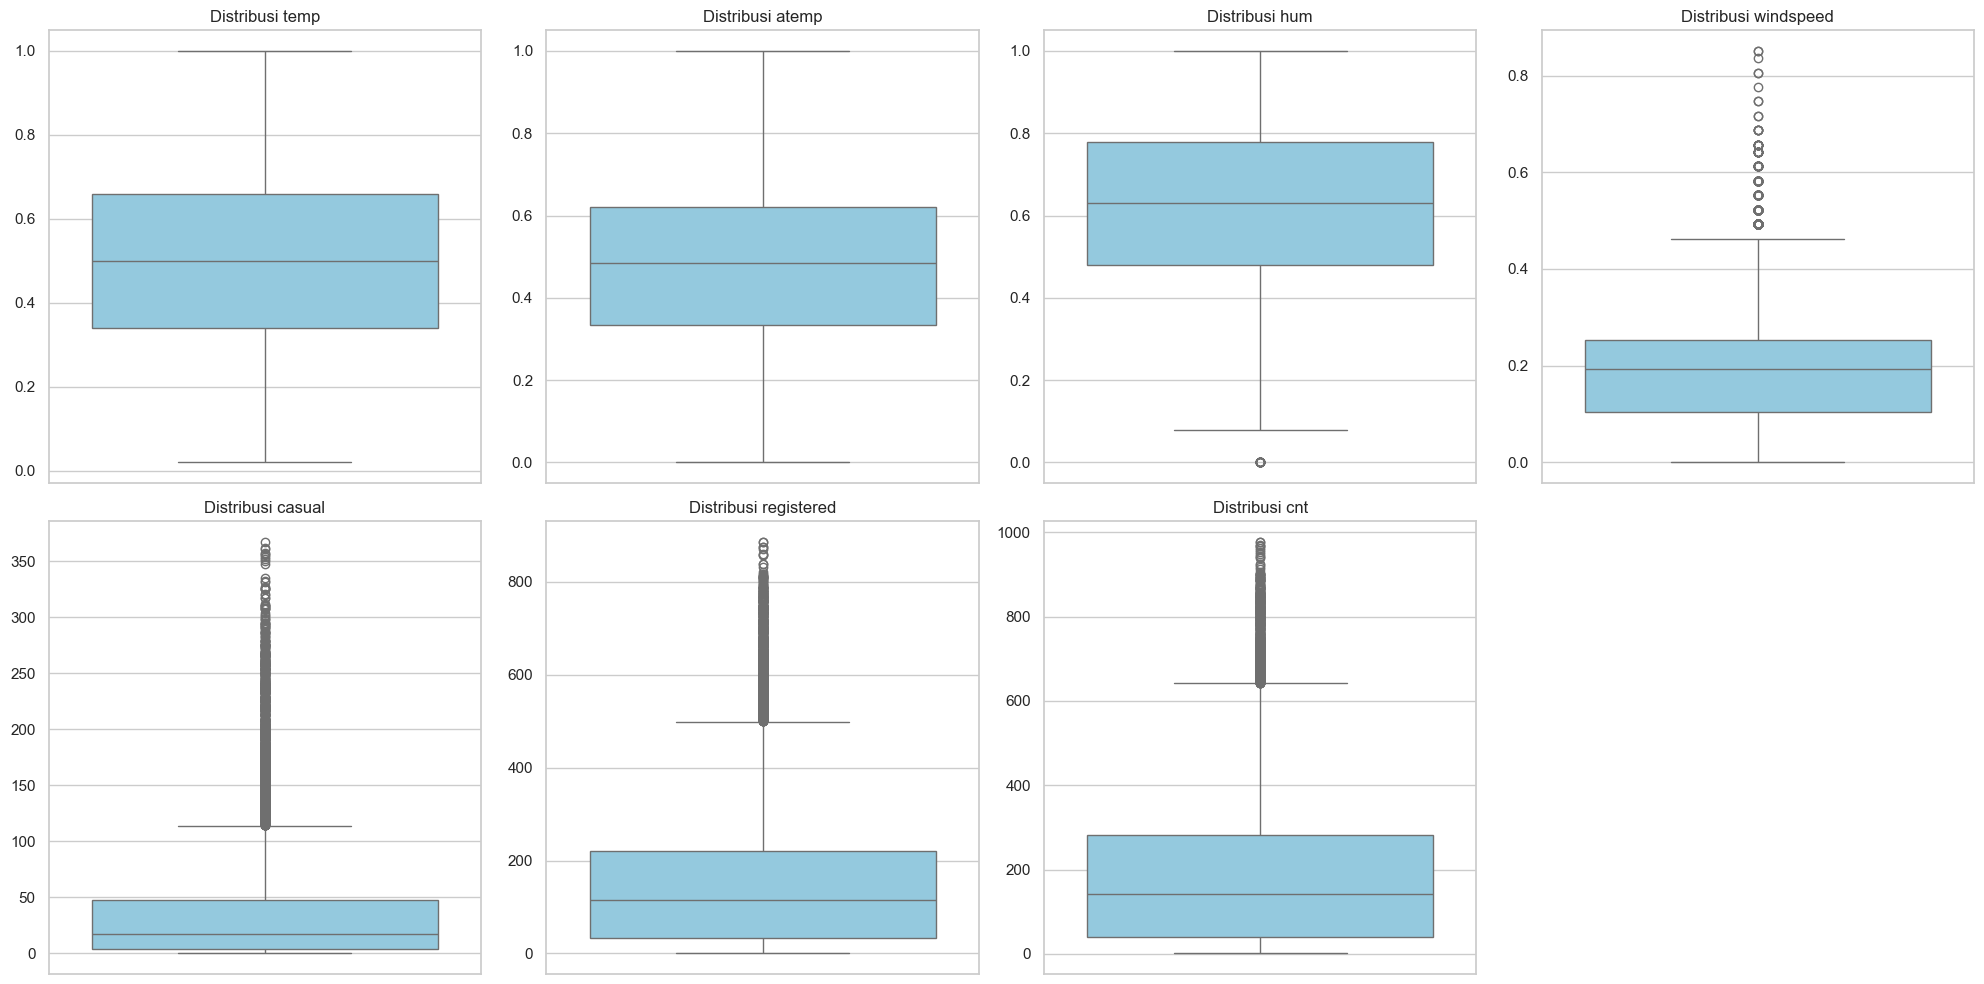

In [126]:
kolom_numerik = ["temp", "atemp", "hum", "windspeed", "casual", "registered", "cnt"]

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(kolom_numerik):
    sns.boxplot(data=data, y=col, ax=axes[i], color='skyblue')
    axes[i].set_title(f"Distribusi {col}", fontsize=12)
    axes[i].set_ylabel("")

for j in range(len(kolom_numerik), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

##### Korelasi Antar Fitur (Korelasi >= 97)

In [127]:
kolom_numerik = ["temp", "atemp", "hum", "windspeed", "casual", "registered", "cnt"]

corr_matrix = data[kolom_numerik].corr()

# Ambil pasangan tanpa duplikat
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.97:
            print(f"{corr_matrix.columns[i]} & {corr_matrix.columns[j]} = {corr_matrix.iloc[i, j]:.2f}")

atemp & temp = 0.99
cnt & registered = 0.97


**Insight:**
- Dataset memiliki kualitas yang cykup baik karena tidak ditemukan missing values maupun data duplikat. Namun, beberapa tipe data belum sesuai, seperti dteday yang masih bertipe object, sehingga perlu dikonversi ke datetime agar analisis berbasis waktu dapat dilakukan dengan lebih akurat.
- Ditemukan outlier pada beberapa variabel, terutama casual, registered, dan cnt, yang menunjukkan kemungkinan adanya lonjakan jumlah pengguna pada kondisi tertentu, seperti jam sibuk atau event tertentu. Selain itu, outlier juga ditemukan pada windspeed dan sedikit pada hum, yang mengindikasikan adanya kondisi cuaca ekstrem.
- Terdapat korelasi yang sangat tinggi antara temp dan atemp (0.99), serta antara registered dan cnt (0.97), yang menunjukkan adanya redundansi informasi (multikolinearitas). Hal ini juga perlu diperhatikan agar tidak terjadinya bias .

### Cleaning Data

##### Mengubah tipe data dteday menjadi datetime

In [128]:
data['dteday'] = pd.to_datetime(data['dteday'])

##### Menghapus Kolom Instant

In [129]:
data.drop(columns=['instant'], inplace=True)

##### Menghapus Kolom Atemp

In [130]:
data.drop(columns=['atemp'], inplace=True)

##### Mengubah angka pada kolom weathersit menjadi kategori asli sesuai dataset

In [131]:
data['weathersit'] = data['weathersit'].map({
    1: 'Clear',
    2: 'Mist/Cloudy',
    3: 'Light Rain/Snow',
    4: 'Heavy Rain/Snow'
})

#### Menangani Outlier

In [132]:
kolom_outlier = ["hum", "windspeed", "casual", "registered", "cnt"]

for col in kolom_outlier:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    data[col] = data[col].clip(lower, upper)

    sisa_outlier = ((data[col] < lower) | (data[col] > upper)).sum()
    
    print(f"{col}: {sisa_outlier} outlier setelah cleaning")

hum: 0 outlier setelah cleaning
windspeed: 0 outlier setelah cleaning
casual: 0 outlier setelah cleaning
registered: 0 outlier setelah cleaning
cnt: 0 outlier setelah cleaning


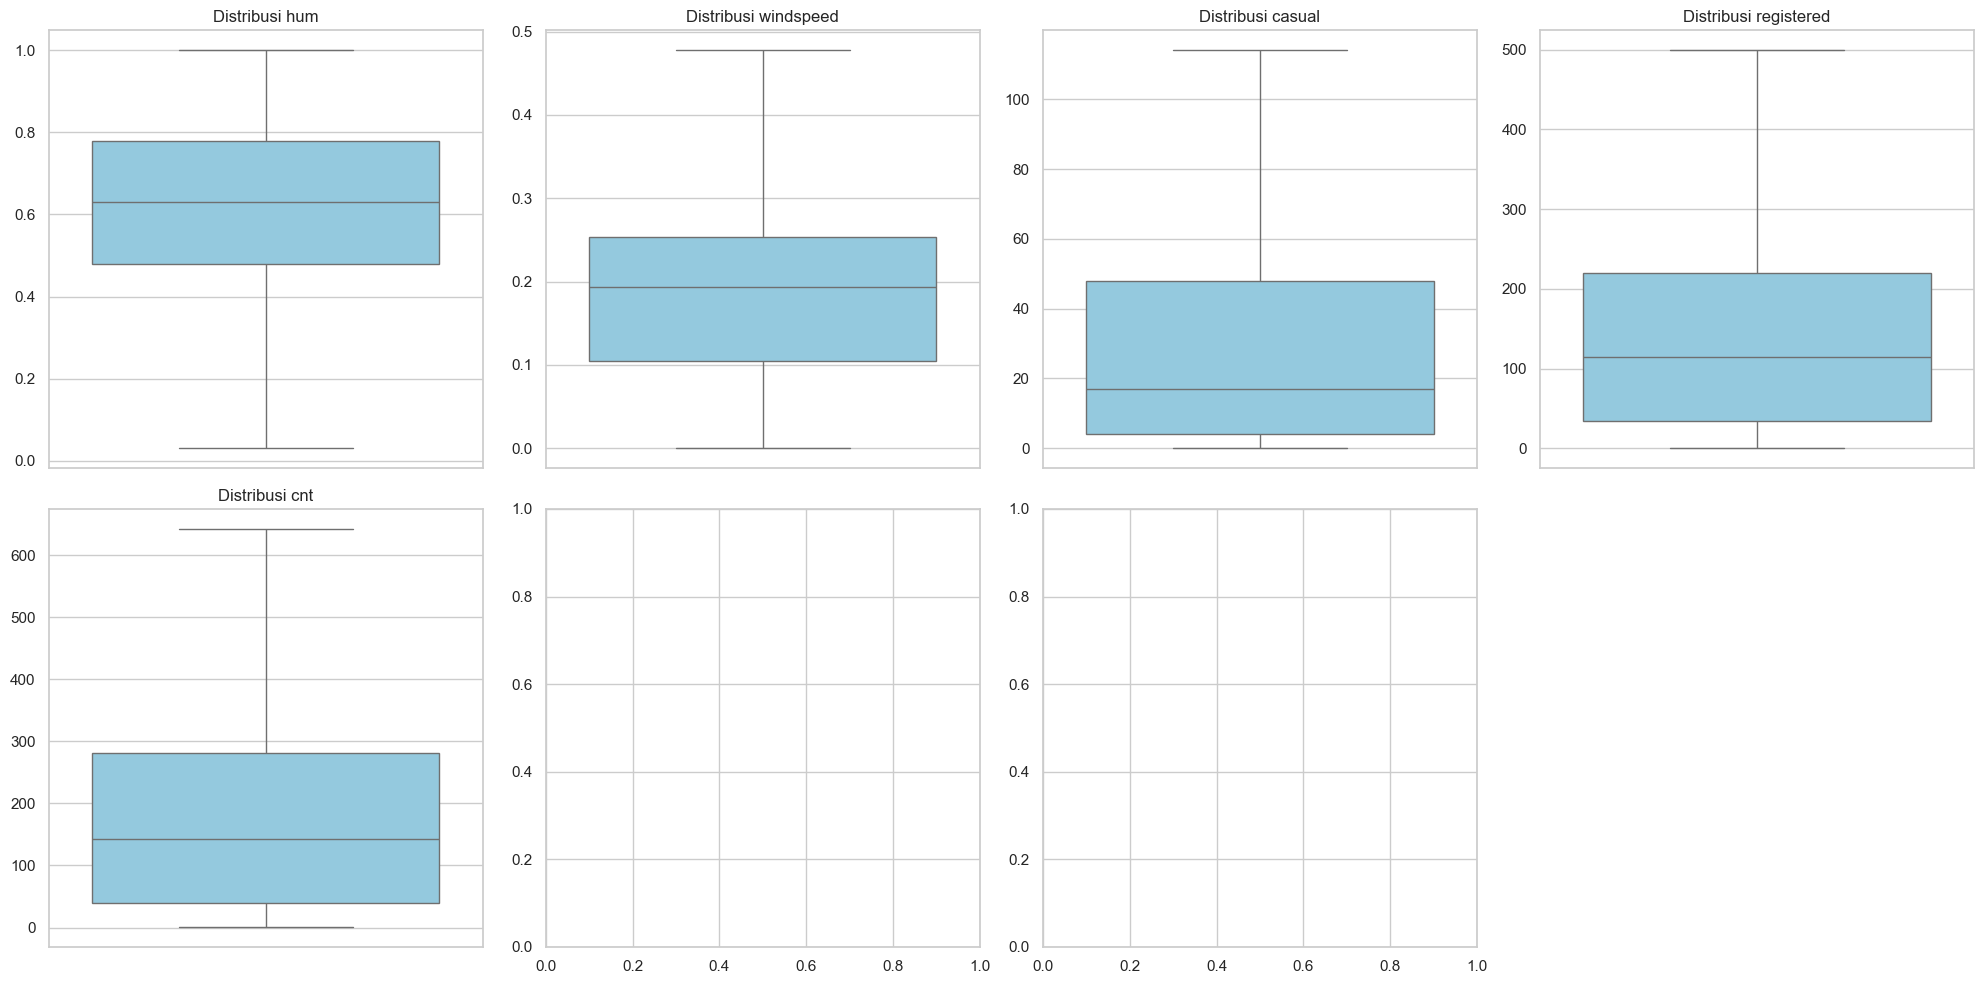

In [133]:
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(kolom_outlier):
    sns.boxplot(data=data, y=col, ax=axes[i], color='skyblue')
    axes[i].set_title(f"Distribusi {col}", fontsize=12)
    axes[i].set_ylabel("")

for j in range(len(kolom_numerik), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Insight:**
- Dilakukan pengubahan tipe data dteday menjadi datetime untuk mempermudah analisis berbasis waktu, serta penghapusan kolom instant yang hanya berfungsi sebagai indeks dan kolom atemp karena memiliki korelasi yang sangat tinggi dengan temp, sehingga dapat mengurangi redundansi data.
- Outlier ditangani dengan membatasi nilai ekstrem ke dalam rentang IQR (caping) tanpa menghapus data. Metode ini dipilih karena lebih mampu menjaga pola asli data dibandingkan dengan penghapusan data (drop) yang dapat menghilangkan informasi penting, serta imputasi yang dapat meratakan distribusi dan mengurangi variasi alami data.

## Exploratory Data Analysis (EDA)

### Explore Pola rata-rata penyewaan per jam

In [134]:
rata_jam = data.groupby("hr")["cnt"].mean().reset_index()
rata_jam

,hr,cnt
0,0,53.898072
1,1,33.375691
2,2,22.869930
3,3,11.727403
4,4,6.352941
5,5,19.889819
6,6,76.044138
7,7,212.064649
8,8,347.059835
9,9,219.309491


### Explore Pola berdasarkan hari (weekday)

In [135]:
rata_hari = data.groupby("weekday")["cnt"].mean().reset_index()
rata_hari

,weekday,cnt
0,0,176.998801
1,1,180.376563
2,2,186.836119
3,3,186.066667
4,4,191.640024
5,5,193.568959
6,6,189.090963


### Explore Rata-rata penyewaan berdasarkan cuaca

In [136]:
cuaca = data.groupby("weathersit")["cnt"].mean().reset_index()
cuaca

,weathersit,cnt
0,Clear,201.057172
1,Heavy Rain/Snow,74.333333
2,Light Rain/Snow,110.587033
3,Mist/Cloudy,173.187060


**Insight:**
- Pola penggunaan sepeda menunjukkan distribusi yang tidak merata sepanjang hari. Jumlah penyewaan sangat rendah pada dini hari (jam 00.00–05.00), kemudian meningkat tajam mulai pagi hari dan mencapai puncak pada jam tertentu, sebelum kembali menurun pada malam hari. Hal ini menunjukkan adanya pola aktivitas harian yang jelas dalam penggunaan sepeda.
- Rata-rata penyewaan sepeda pada setiap hari (weekday) tidak menunjukkan perbedaan yang signifikan, meskipun terdapat sedikit peningkatan pada akhir pekan. Hal ini mengindikasikan bahwa penggunaan sepeda cukup konsisten sepanjang minggu.
- Terlihat bahwa semakin buruk kondisi cuaca (dari kategori 1 ke 4), rata-rata jumlah penyewaan sepeda cenderung menurun. Hal ini menunjukkan bahwa faktor lingkungan kemungkinan berperan dalam mempengaruhi perilaku pengguna.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

C:\Users\lenovo\AppData\Local\Temp\ipykernel_11368\38847246.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


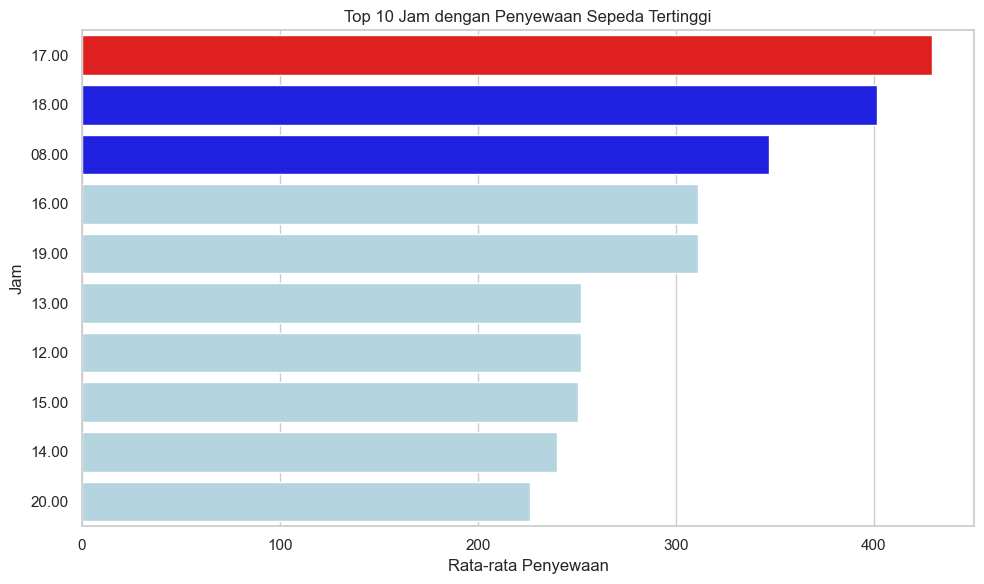

In [150]:
# rata-rata per jam
jam_agg = data.groupby("hr")["cnt"].mean().reset_index()

# ambil top 10 tertinggi
top10 = jam_agg.sort_values("cnt", ascending=False).head(10)

# urutkan dari tertinggi ke terendah (biar ranking)
top10 = top10.sort_values("cnt", ascending=False)

# ubah jam jadi format 08.00
top10["hr"] = top10["hr"].apply(lambda x: f"{int(x):02d}.00")

# warna (custom sesuai ranking)
colors = []
for i in range(len(top10)):
    if i == 0:
        colors.append("red")          # rank 1
    elif i in [1, 2]:
        colors.append("blue")         # rank 2 & 3
    else:
        colors.append("lightblue")    # sisanya

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x="cnt",
    y="hr",
    palette=colors
)

plt.title("Top 10 Jam dengan Penyewaan Sepeda Tertinggi")
plt.xlabel("Rata-rata Penyewaan")
plt.ylabel("Jam")

plt.tight_layout()
plt.show()

### Pertanyaan 2:

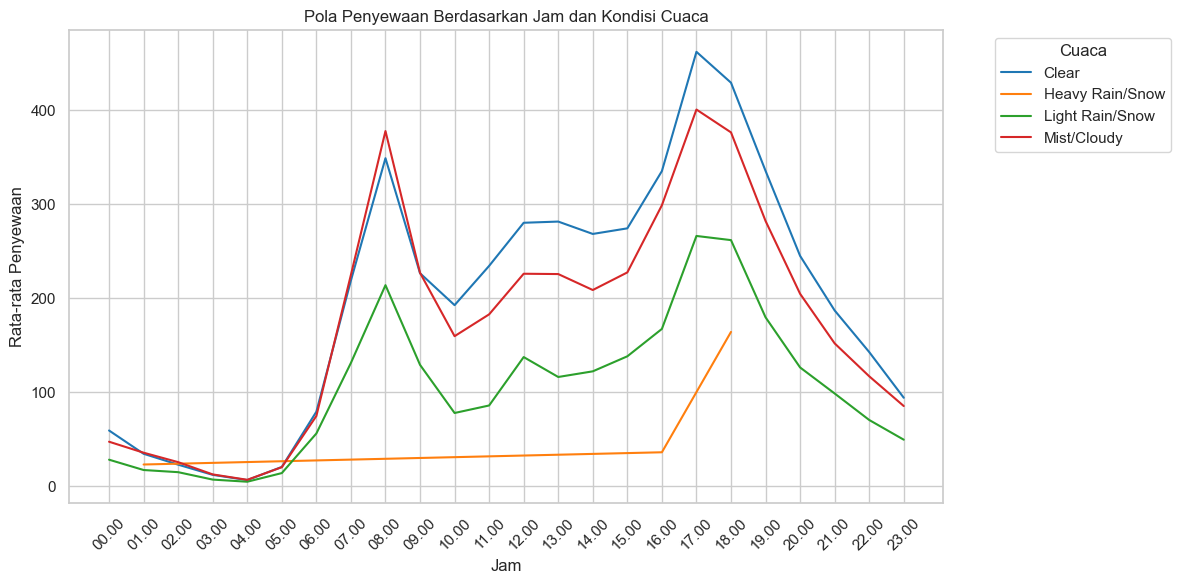

In [151]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

# ubah pivot jadi format panjang
pivot_weather = data.pivot_table(
    values="cnt",
    index="hr",
    columns="weathersit",
    aggfunc="mean"
).reset_index()

pivot_weather = pivot_weather.melt(
    id_vars="hr",
    var_name="weathersit",
    value_name="cnt"
)

# ubah format jam jadi 08.00
pivot_weather["hr"] = pivot_weather["hr"].apply(lambda x: f"{int(x):02d}.00")

plt.figure(figsize=(12,6))

sns.lineplot(
    data=pivot_weather,
    x="hr",
    y="cnt",
    hue="weathersit",
    palette="tab10",
    errorbar=None
)

plt.title("Pola Penyewaan Berdasarkan Jam dan Kondisi Cuaca")
plt.xlabel("Jam")
plt.ylabel("Rata-rata Penyewaan")

# biar urut jam (penting!)
plt.xticks(rotation=45)

plt.legend(title="Cuaca", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

**Insight:**
- Pertanyaan 1 :
Berdasarkan hasil visualisasi tersebut, terlihat bahwa waktu dengan jumlah penyewaan sepeda tertinggi terjadi pada pukul 17.00 sebagai puncak utama, diikuti oleh pukul 18.00 dan 08.00, serta didukung oleh jam 16.00 dan 19.00 sebagai periode dengan permintaan tinggi, yang menunjukkan bahwa penggunaan sepeda sangat terkonsentrasi pada waktu sore hari dan pagi hari kondisi ini mengindikasikan bahwa sepeda paling banyak digunakan pada saat jam pulang kerja dan berangkat kerja (commuting), sehingga periode antara pukul 16.00–19.00 dan sekitar pukul 08.00 merupakan waktu kritis dengan permintaan tertinggi yang perlu menjadi fokus utama dalam pengelolaan dan distribusi ketersediaan sepeda.
- Pertanyaan 2 :
Kondisi cuaca terbukti mempengaruhi jumlah penyewaan sepeda secara signifikan, di mana jumlah penyewaan tertinggi terjadi pada kondisi cuaca cerah, sementara pada kondisi cuaca yang semakin buruk seperti hujan atau salju, jumlah penyewaan mengalami penurunan yang cukup drastis. Penurunan paling besar terlihat pada cuaca buruk terutama di luar jam sibuk, sedangkan pada jam sibuk seperti pagi dan sore hari, penyewaan sepeda masih tetap terjadi meskipun dalam jumlah yang lebih rendah, sehingga menunjukkan bahwa meskipun cuaca menjadi faktor penting yang menurunkan minat penggunaan, kebutuhan pengguna pada waktu tertentu (khususnya untuk aktivitas rutin) tetap mendorong penggunaan sepeda.

## Analisis Lanjutan (Opsional)

#### CLUSTERING Non-ML (Jam Sibuk vs Tidak Sibuk)

In [139]:
def time_cluster(hr):
    if 6 <= hr <= 9:
        return "Jam Sibuk Pagi"
    elif 10 <= hr <= 15:
        return "Siang Hari (Normal)"
    elif 16 <= hr <= 19:
        return "Jam Sibuk Sore"
    else:
        return "Malam Hari (Sepi)"

data["cluster_waktu"] = data["hr"].apply(time_cluster)

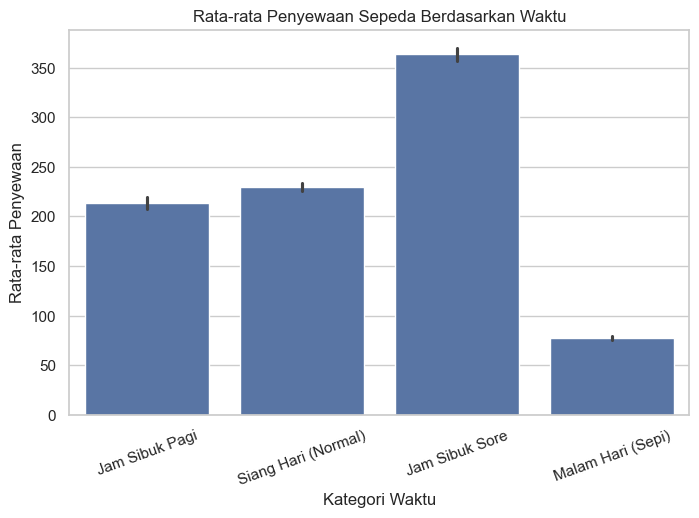

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=data,
    x="cluster_waktu",
    y="cnt",
    estimator="mean",
    order=[
        "Jam Sibuk Pagi",
        "Siang Hari (Normal)",
        "Jam Sibuk Sore",
        "Malam Hari (Sepi)"])

plt.title("Rata-rata Penyewaan Sepeda Berdasarkan Waktu")
plt.xlabel("Kategori Waktu")
plt.ylabel("Rata-rata Penyewaan")
plt.xticks(rotation=20)
plt.show()

## Conclusion

- Conclution Pertanyaan 1
Penyewaan sepeda paling tinggi terjadi pada jam sibuk sore (sekitar 16.00–19.00) dengan puncaknya pukul 17.00, diikuti oleh jam sibuk pagi (sekitar 08.00). Hal ini menunjukkan bahwa penggunaan sepeda didominasi oleh aktivitas komuter (berangkat dan pulang kerja/sekolah), sehingga waktu kritis permintaan terjadi pada dua periode utama tersebut.
- Conclution Pertanyaan 2
Kondisi cuaca memiliki pengaruh yang signifikan terhadap jumlah penyewaan sepeda, di mana cuaca cerah menghasilkan jumlah penyewaan tertinggi, sedangkan cuaca buruk seperti hujan atau salju menyebabkan penurunan tajam. Namun, pada jam sibuk (pagi dan sore), penggunaan sepeda tetap terjadi meskipun cuaca kurang baik, yang menunjukkan bahwa faktor kebutuhan aktivitas rutin masih menjadi pendorong utama penggunaan.
- Conclution Analisis Lanjutan
Hasil clustering waktu menunjukkan bahwa Jam Sibuk Sore memiliki rata-rata penyewaan tertinggi, diikuti oleh Jam Sibuk Pagi, sementara Siang Hari berada pada kondisi stabil dan Malam Hari menjadi periode dengan permintaan terendah. Hal ini memperkuat temuan bahwa pola penggunaan sepeda sangat dipengaruhi oleh aktivitas harian masyarakat, sehingga strategi distribusi dan ketersediaan sepeda perlu difokuskan pada dua jam sibuk utama untuk meningkatkan efisiensi operasional.